# 머신러닝 회귀모델 실습
- Kaggle data : https://www.kaggle.com/mustafaali96/weight-height
- 데이터 컬럼 : Gender, Height, Weight
- 목표(target) : 사람의 키에 따른 몸무게 예측하기
- 학습기(Estimator) : LinearRegression


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error

## 데이터 로딩 및 단위 변경

In [9]:
# read weight-height dataset
data = "datas_ml/weight-height.csv"
wh_df = pd.read_csv(data)

In [10]:
wh_df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


### [문제해결] 컬럼 단위를 우리에게 익숙한 값으로 변경하기
- 키 : inch -> cm, 1inch = 2.54cm 
- 몸무게 : lb(파운트) -> kg, 1lb = 0.4563kg 

#### 방법

In [11]:
# read weight-height dataset
data = "datas_ml/weight-height.csv"
wh_df = pd.read_csv(data)

# 키 변경하기
wh_df["Height"] = np.ceil(wh_df["Height"] * 2.54).astype(int)

# 몸무게 변경하기
wh_df["Weight"] = np.ceil(wh_df["Weight"] * 0.4563).astype(int)

wh_df.head()

,Gender,Height,Weight
0,Male,188,111
1,Male,175,75
2,Male,189,98
3,Male,183,101
4,Male,178,95


In [12]:
wh_df.shape

(10000, 3)

# 데이터 탐색

In [13]:
wh_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Gender  10000 non-null  str  
 1   Height  10000 non-null  int64
 2   Weight  10000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 234.5 KB


In [13]:
#[문제] 기초 통계량 확인
wh_df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,169.073300,74.163100
std,9.775269,14.651552
min,138.000000,30.000000
25%,162.000000,62.000000
50%,169.000000,74.000000
75%,176.000000,86.000000
max,201.000000,124.000000


In [10]:
wh_df['Gender'].describe()
# 데이터의 범주를 알려준다. 

count     10000
unique        2
top        Male
freq       5000
Name: Gender, dtype: object

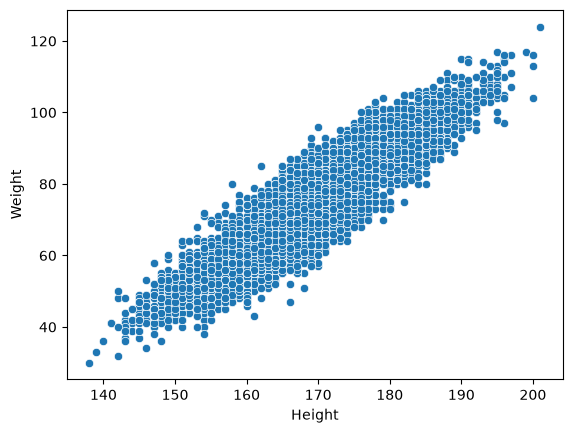

In [14]:
# 키와 몸무게 분포 확인
sns.scatterplot(data=wh_df, x = 'Height', y = 'Weight')
plt.show()

# 1. 키에 따른 몸무게 예측
## 학습, 테스트 데이터 준비
- Feature(x)와 label(y) 데이터 분리 

In [15]:
x = wh_df["Height"] # 입력데이터
y = wh_df["Weight"] # 정답데이터

In [13]:
y[:5]

0    111
1     75
2     98
3    101
4     95
Name: Weight, dtype: int64

## 80%는 트레이닝 데이터, 20%는 테스트 데이터로 나누기
- random_seed 값 주기
- stratify=y 설정은
  - target이 classification인 경우
  - feature가 2개이상 있을 때 사용

In [16]:
# 학습, 테스트 데이터셋으로 분할
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)
# test_size 을 정해졌을 경우 train_size 또한 암묵적으로 결정이 된다.
# random_state 의 경우 데이터 분할 재현을 의미한다 
# Split arrays or matrices into random train and test subsets.

# Learning the parameters of a prediction function and testing it on the same data is a methodological mistake: Overfitting
# Overfitting 을 방지하기 위해 주어진 데이터 셋을 예측과 결과에 대한 데이터셋이 중첩되지 않게 분리 

In [17]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((8000,), (2000,), (8000,), (2000,))

## 회귀 모델 학습하기
- 선형회귀(Linear Regression

In [50]:
# 회귀 모델 알고리즘 객체 생성
model_lr = LinearRegression()

In [51]:
model_lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
x_train_2d = x_train.values.reshape(-1, 1)

x_train.shape, x_train_2d, type(x_train_2d)

((8000,),
 array([[159],
        [151],
        [164],
        ...,
        [173],
        [168],
        [175]], shape=(8000, 1)),
 numpy.ndarray)

hat{y} = b_0 + b_1x

In [ ]:
# x_train 데이터가 1D 이면 오류 발생함

model_lr.fit(x_train_2d, y_train)
# x_train 의 입력 데이터의 경우 2차원의 데이터여야만 한다.
# coefficient : 기울기
# Xw + b = y
# coef value = w
# intercept = b

# 회귀모델에 fit 을 사용하여 최적의 직선에 대한 학습을 수행한다.
# LinearRegression은 주어진 x, y 데이터 사이에서 가장 적절한 직선을 찾습니다.
# 여기서 ŷ = wx + b 식을 사용하여 예측 값을 계산한다
# x: 입력 데이터
# w: coefficient, 기울기
# b: intercept, 절편
# ŷ: 모델의 예측값

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.39]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-160.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[870.1]


In [54]:
x_train.shape

(8000,)

In [55]:
# x는 2차원이어야 함.
x_train_2d = x_train.values.reshape(-1,1)

In [ ]:
# 모델 학습
# model_lr.fit(x_train, y_train)  <-- x_train은 2D 여야함.
model_lr.fit(x_train_2d, y_train)
# X.shape = (sample 개수, feature 개수)
# (5, 1) 일 경우
# 5 = 사람 5명
# 1 = 입력 특성 1개(키)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.39]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-160.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[870.1]


#### [tip] feature가 1개인 경우, 학습 및 테스트시 reshape(-1,1)로 차원을 바꿔 주는 이유
-  학습기는 기본적으로 feature 2개 이상의 input이 들어간다고 가정하고 만들어뒀다.(2차원 array)
-  현재 키(height)만 있음.(1차원 vector)

## 학습 모델 테스트

In [ ]:
#print(type(x_test))
print("테스트 데이터", x_test.values)
print()
print(x_train_2d)

# 테스트의 데이터와 학습되어 있는 데이터의 차원이 일치하지 않을 경우 제대로된 결과를 얻을 수 없다

테스트 데이터 [174 165 189 ... 172 163 159]

[[159]
 [151]
 [164]
 ...
 [173]
 [168]
 [175]]


In [ ]:
y_pred = model_lr.predict(x_test.values)
# ValueError: Expected 2D array, got 1D array instead:

ValueError: Expected 2D array, got 1D array instead:
array=[174 165 189 ... 172 163 159].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [31]:
# 테스트 데이터에 대한 예측을 수행
y_pred = model_lr.predict(x_test.values.reshape(-1,1))
# 앞서 차원이 1차원, 2차원으로 다르게 맞춰져 있어서 제대로 된 결과가 나올 수 없던 값을 개선한다.

In [ ]:
y_pred
# 예측값, x_test에 대한 예측 y 값을 의미한다.

array([ 80.93276628,  68.46283818, 101.71597979, ...,  78.16167115,
        65.69174304,  60.14955277], shape=(2000,))

In [34]:
y_test[:5]

937      95
9355     68
2293    100
192      94
8675     59
Name: Weight, dtype: int64

In [ ]:
model_lr.coef_

array([1.38648312])

In [ ]:
model_lr.intercept_

np.float64(-160.11720767437617)

## 모델 성능 평가하기

- MSE(Mean Squared Error)를 측정하기
    오차의 제곱값의 평균을 구한다. 이 경우 평균 오차 값을 구할 수 있다.

- RMSE(Root Mean Squared Error)를 측정하기
    Mean Squared Error 에 루트를 씌운 값에 해당한다. 이를 사용하여 오차 값을 구한다.

In [ ]:
y_test[:5]

937     94.192251
9355    67.971504
2293    99.389349
192     93.037587
8675    58.119952
Name: Weight, dtype: float64

In [40]:
# MSE(Mean Squared Error)
# MSE = mean_squared_error(y_test, y_pred)
# 실제 값 y와 y hat이 인자로 주어져야 한다.

# RMSE(Root Mean Squared Error)를 측정하기
# RMSE = np.sqrt(MSE)
RMSE = root_mean_squared_error(y_test, y_pred)

# print('MSE :', MSE)
print('RMSE :', RMSE)

# 결과는 도메인마다 다름

RMSE : 5.657135251273898


In [ ]:
# MSE(Mean Squared Error)
MSE = mean_squared_error(y_test, y_pred)
# 실제 값 y와 y hat이 인자로 주어져야 한다.

# RMSE(Root Mean Squared Error)를 측정하기
RMSE = np.sqrt(MSE)
# RMSE = root_mean_squared_error(MSE)

print('MSE :', MSE)
print('RMSE :', RMSE)

# 결과는 도메인마다 다름
# 문제 A: 사람 몸무게 예측
# 평균 몸무게 ≈ 70kg
# RMSE = 5kg
# → 꽤 괜찮을 수도 있음

# 문제 B: 반도체 두께 예측
# 평균 두께 ≈ 0.1mm
# RMSE = 5mm
# → 완전히 잘못된 모델

# 위와 같이 어떠한 도메인에서 어떠한 오차값의 차이가 나왔는지에 대한 평가가 중요하다

MSE : 32.00317925120579
RMSE : 5.657135251273898


## ML 모델 일반화

### [문제해결] 내 몸무게 예측해보기
- [힌트] x_train 또는 x_test와 같은 shape으로 입력
- 일반화 테스트

키 165cm -> 몸무게 ?  : [[165]]
- 방법1 :
<pre>
    lr.predict([[165]])
</pre>
- 방법2:
<pre>
    y_pred2 = lr.predict(np.array([177,185]).reshape(-1,1))
    y_pred2
</pre>
- 방법3:
<pre>
my_height1 = pd.Series(172)
type(my_height1)
model_lr.predict(my_height1.values.reshape(-1,1))    
</pre>

### [문제해결] 내 키와 내 가족 한사람 더추가 해서 예측해보기
- [힌트] x와 같은 shape으로 입력

In [ ]:
a = model_lr.coef_ # 모델의 가중치(기울기) w
b = model_lr.intercept_ # 모델의 편향(절편) b
# y_pred = a * x + b / Xw + b = y_pred
y = a * 165 + b
y

array([68.46283818])

In [45]:
my_data = [[165]]
y_pred2 = model_lr.predict(my_data)
y_pred2

array([68.46283818])

## 예측 결과 시각화

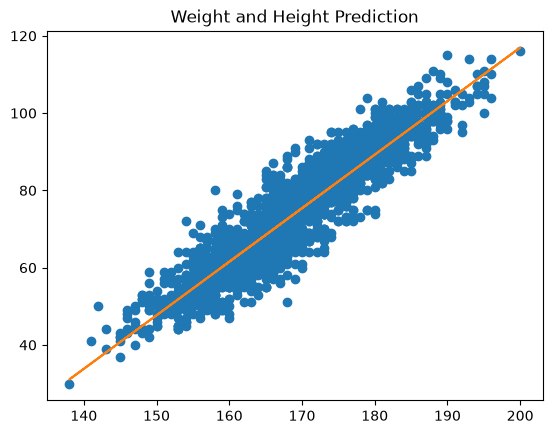

In [49]:
plt.plot(x_test, y_test, 'o')
plt.plot(x_test, y_pred)
plt.title('Weight and Height Prediction')
plt.show()

# 키와 성별에 따른 몸무게 예측하기
- feature 갯수 2개로 학습하기
- Gender, height 데이터로 linear regression 모델 만들기
- Gender는 범주형 데이터임 : One Hot Encoding으로 변환하기

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## 데이터 로딩 및 가공

In [ ]:
# read weight-height dataset
data = "datas_ml/weight-height.csv"
gwh_df = pd.read_csv(data)
gwh_df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [ ]:
# 인치, 파운드 -> cm, kg으로 변환
gwh_df["Height"] = gwh_df["Height"] * 2.54
gwh_df["Weight"] = gwh_df["Weight"] * 0.4563
# read weight-height dataset
gwh_df.head()

,Gender,Height,Weight
0,Male,187.571423,110.376033
1,Male,174.706036,74.062269
2,Male,188.239668,97.073652
3,Male,182.196685,100.405379
4,Male,177.499761,94.157414


<Figure size 1000x600 with 0 Axes>

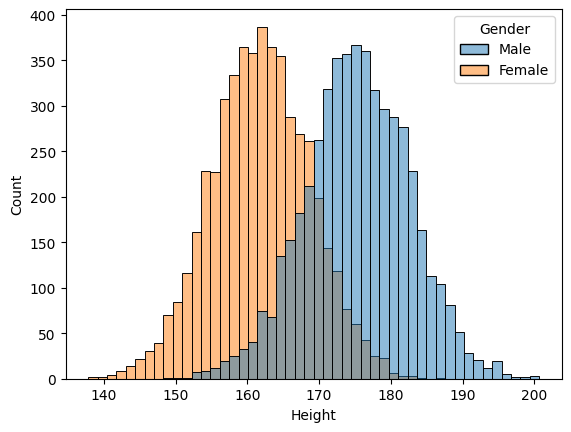

<Figure size 1000x600 with 0 Axes>

In [ ]:
# feature distribution
sns.histplot(data=gwh_df, x="Height", hue="Gender")
plt.figure(figsize=(10,6))

## ML을 위한 feature Engineering
- 범주형 데이터 숫자로 변환 : One Hot Encoding

In [ ]:
gwh_df['Gender'].value_counts()

Gender
Male      5000
Female    5000
Name: count, dtype: int64

In [ ]:
# Gender 컬럼을 숫자로 변환
gwh_df['Gender'] = gwh_df['Gender'].map({"Male": 0, "Female": 1})
gwh_df.head()

,Gender,Height,Weight
0,0,187.571423,110.376033
1,0,174.706036,74.062269
2,0,188.239668,97.073652
3,0,182.196685,100.405379
4,0,177.499761,94.157414


## 학습, 테스트 데이터 준비

In [ ]:
# X = Gender, Height
X = gwh_df.drop(columns='Weight')

# y = Weight
y = gwh_df['Weight']

In [ ]:
X.head()

,Gender,Height
0,0,187.571423
1,0,174.706036
2,0,188.239668
3,0,182.196685
4,0,177.499761


In [ ]:
# train data : test data로 분할 (8 : 2)


In [ ]:
X_train

,Gender,Height
9254,1,155.934775
1561,0,189.731998
1670,0,174.009850
6087,1,167.125690
6669,1,170.590986
...,...,...
5734,1,160.908969
5191,1,149.508528
5390,1,163.386531
860,0,175.449210


## 회귀 모델 학습

In [ ]:
# 학습모델 객체생성, 학습, 테스트
model_lr2 = LinearRegression()
model_lr2.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 테스트 및 성능 평가

In [ ]:
y_pred = model_lr2.predict(X_test)
y_pred

array([75.55642225, 84.77185534, 78.14549722, ..., 57.84501902,
       79.97209066, 48.15240468], shape=(2000,))

In [ ]:
X_test.columns

Index(['Gender', 'Height'], dtype='object')

### [문제해결] MSE, RMSE 구하기

In [ ]:
# MSE(Mean Squared Error)를 측정하기
MSE = mean_squared_error(y_test, y_pred)

# RMSE(Root Mean Squared Error)를 측정하기
RMSE = np.sqrt(MSE)

print('MSE :', MSE)
print('RMSE :', RMSE)

# 결과는 도메인마다 다름

MSE : 21.080039418120673
RMSE : 4.591300405998356


## ML 모델 일반화
### [문제해결] 키와, 성별 정보로 일반 데이터를 구성하여 예측하기

In [ ]:
my_test = 
my_test

array([[  1, 165]])

In [ ]:
model_lr2.predict(my_test)

C:\Users\magpi\miniconda3\envs\eda_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([65.39940251])

## 예측 결과 시각화

In [ ]:
X_test[:5]

,Gender,Height
6252,1,174.465570
4684,0,174.826508
1731,0,168.651246
4742,0,182.700524
4521,0,170.288974


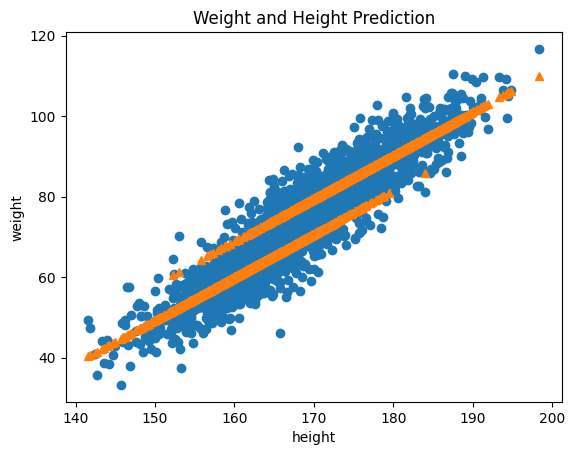

In [ ]:
# 테스트 데이터(X)에 따른 실제 몸무게(y)와 예측 데이터(y^) 그래프 그리기
plt.plot(X_test.loc[:,'Height'], y_test, 'o')  # 실제값 표시
plt.plot(X_test.loc[:,'Height'], y_pred, '^')  # 예측값 표시
plt.title('Weight and Height Prediction')
plt.xlabel('height')
plt.ylabel('weight')
plt.show()